In [3]:
import numpy as np
import matplotlib.pyplot as plt
import re
import surfinBH
import lal
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid
import gwsurrogate as gws
lal.swig_redirect_standard_output_error(False)

/home/giacomo/Thesis/Entropy-conjecture/.venv/lib/python3.12/site-packages/lalsimulation/_lalsimulation_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


True

In [4]:
def entropy(M, J):
    M = np.asarray(M)
    J = np.asarray(J)

    arg_sqrt = M**2 - ((J**2)/(M**2))
    arg_sqrt = np.where(arg_sqrt < 0, np.nan, arg_sqrt)
    S = 2 * np.pi * M * (M + np.sqrt(arg_sqrt))
    
    return S

In [5]:
fit = surfinBH.LoadFits('NRSur7dq4EmriRemnant')

Loaded NRSur7dq4EmriRemnant fit.


In [114]:
q = 4        
m1 = q / (1 + q) 
m2 = 1 / (1 + q) 
eta = (m1 * m2) 

chi1_z = 0.5
chi2_z = 0.5

S1 = chi1_z * (m1**2)
S2 = chi2_z * (m2**2)

a = np.linspace(100.0,7.0, 1000)

In [115]:
spin1 = [0.0, 0.0, chi1_z]
spin2 = [0.0, 0.0, chi2_z]
mf_surr, chif_vec, *_ = fit.all(q, spin1, spin2)
chif_surr = np.linalg.norm(chif_vec)
Jf_surr = chif_surr * (mf_surr**2)

S_surr_final = entropy(mf_surr, Jf_surr)
print(S_surr_final)

9.847211398441091


2PN ANALYSIS

In [76]:
# function to calculate the maximum entropy at 2PN
#arXiv:1310.1528
#arXiv:1310.1528
#arXiv:gr-qc/0605140

def get_max_2PN(q, chi1_z, chi2_z, a):
    
    m1 = q / (1.0 + q)
    m2 = 1.0 / (1.0 + q)
    eta = m1 * m2
    delta = m1 - m2  

    S1 = chi1_z * (m1**2)
    S2 = chi2_z * (m2**2)
    
    S_L = S1 + S2
    Sigma_L = chi1_z * m1 - chi2_z * m2
    
    S_ss = S1 * S2

    e1 = -3.0/4.0 - eta/12.0
    e1_5 = (14.0/3.0) * S_L + 2.0 * delta * Sigma_L
    e2 = -27.0/8.0 + (19.0/8.0)*eta - (eta**2)/24.0 - S_ss

    l1 = 3.0/2.0 + eta/6.0
    l1_5 = -(35.0/6.0) * S_L - 2.5 * delta * Sigma_L
    l2 = 27.0/8.0 - (19.0/8.0)*eta + (eta**2)/24.0 + 0.5 * S_ss
    
    M_tot_2PN = np.zeros_like(a)
    J_tot_2PN = np.zeros_like(a)
    
    for i, r in enumerate(a):
    
        x = 1.0 / r

        E_bind_2PN = - (eta * x / 2.0) * (1.0 + e1*x + e1_5*(x**1.5) + e2*(x**2))
        M_tot_2PN[i] = 1.0 + E_bind_2PN 

        L_orb_2PN = (eta / np.sqrt(x)) * (1.0 + l1*x + l1_5*(x**1.5) + l2*(x**2))
        
        J_tot_2PN[i] = L_orb_2PN + S_L 
        
    S_inst = entropy(M_tot_2PN, J_tot_2PN)
    
    valid = S_inst[~np.isnan(S_inst)]
    max_val = np.max(valid) if len(valid) > 0 else np.nan
    
    return M_tot_2PN, J_tot_2PN, S_inst, max_val

In [116]:
M_array, J_array, S, max_val = get_max_2PN(q, chi1_z, chi2_z, a)
print(max_val)
print(S_surr_final)
print( 'delta S = ', np.abs(max_val - S_surr_final))

9.449225970786022
9.847211398441091
delta S =  0.39798542765506895


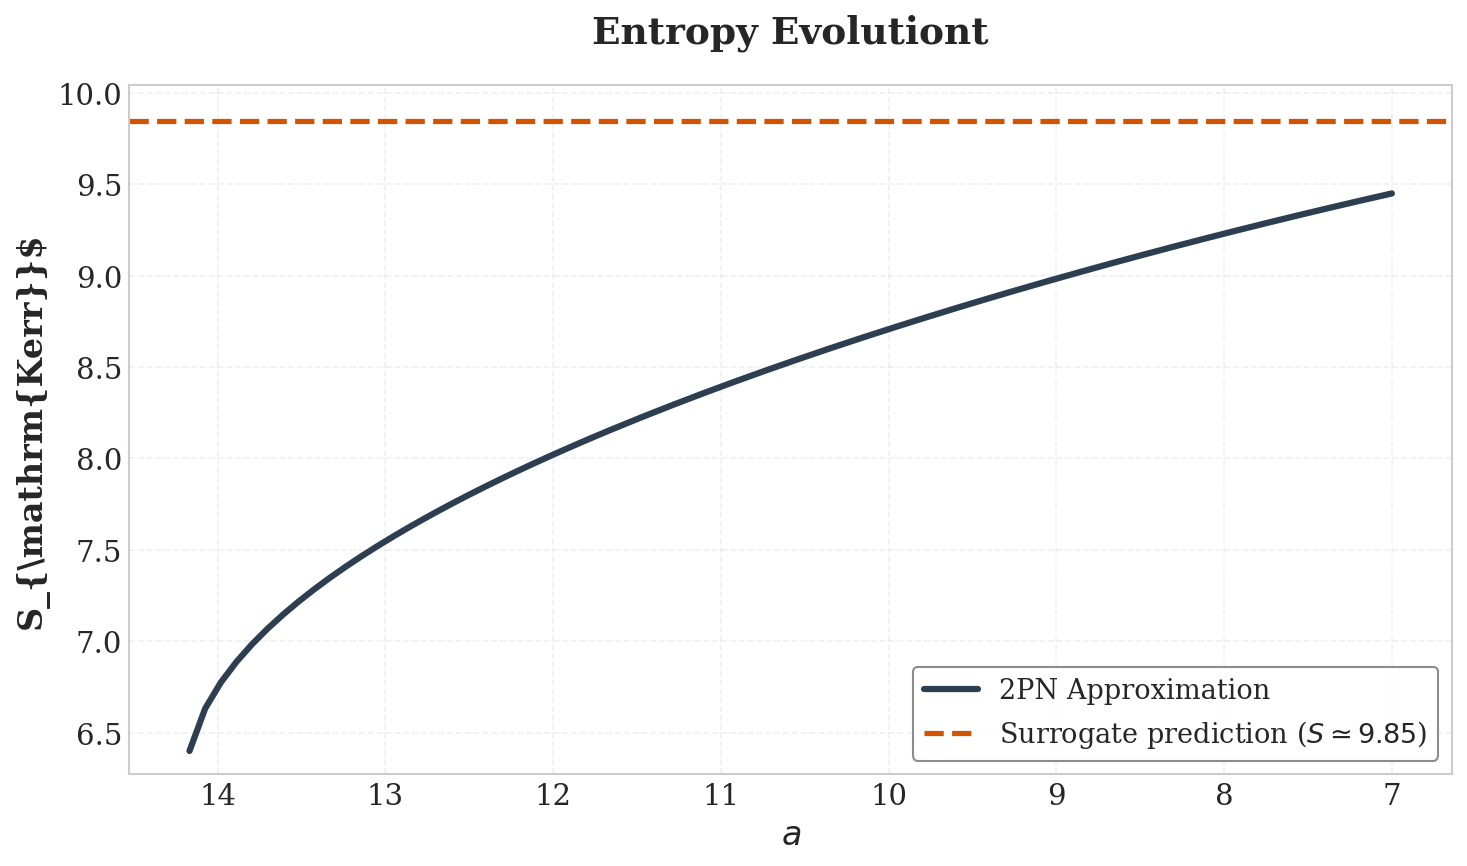

In [117]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.plot(a, S, color='#2c3e50', lw=3.0, label=r'2PN Approximation')

ax.axhline(S_surr_final, color='#d35400', linestyle='--', lw=2.5, 
           label=rf'Surrogate prediction ($S \simeq {S_surr_final:.2f}$)')
ax.invert_xaxis()
ax.set_xlabel(r'$a$', fontweight='bold')
ax.set_ylabel(r'S_{\mathrm{Kerr}}$', fontweight='bold')
ax.set_title(r'Entropy Evolutiont', fontweight='bold', pad=20)
y_min = min(np.nanmin(S), S_surr_final) * 0.98
y_max = max(np.nanmax(S), S_surr_final) * 1.02
ax.set_ylim(y_min, y_max)
ax.legend(loc='best', frameon=True, facecolor='white', edgecolor='gray', framealpha=0.9)
plt.tight_layout()
plt.show()

PADE' INTERPOLATION

In [15]:
def pade_2_1(x, p0, p1, p2, q1):
    return (p0 + p1 * x + p2 * x**2) / (1.0 + q1 * x)

In [118]:
valid_mask = ~np.isnan(S)
a_valid = a[valid_mask]
M_valid = M_array[valid_mask]
J_valid = J_array[valid_mask]

sort_idx = np.argsort(a_valid)
a_fit = a_valid[sort_idx]
M_fit = M_valid[sort_idx]
J_fit = J_valid[sort_idx]
S_fit = S[valid_mask][sort_idx]

x_fit = 1.0 / np.sqrt(a_fit)

initial_guess = [1.0, 1.0, 1.0, 1.0]
lower_bounds = [-np.inf, -np.inf, -np.inf, 0.0]
upper_bounds = [np.inf, np.inf, np.inf, np.inf]

popt_M, _ = curve_fit(pade_2_1, x_fit, M_fit, p0=initial_guess, 
                      bounds=(lower_bounds, upper_bounds), maxfev=20000)
popt_J, _ = curve_fit(pade_2_1, x_fit, J_fit, p0=initial_guess, 
                      bounds=(lower_bounds, upper_bounds), maxfev=20000)

a_extrap = np.linspace(np.min(a_fit), 1.0, 1000)
x_extrap = 1.0 / np.sqrt(a_extrap)

M_extrap = pade_2_1(x_extrap, *popt_M)
J_extrap = pade_2_1(x_extrap, *popt_J)
ENT_extrap = entropy(M_extrap, J_extrap)

a_full = np.concatenate([a_fit, a_extrap])
ENT_full = np.concatenate([S_fit, ENT_extrap])

idx_max = np.nanargmax(ENT_full)
a_max_entropy = a_full[idx_max]
S_max_entropy = ENT_full[idx_max]

print(f"Maximum with Padé at a =      {a_max_entropy:.3f}")
print("2PN Padé max entropy =       ", S_max_entropy)
print("Predicted entropy =          ", S_surr_final)
print("Delta S =                    ", np.abs(S_max_entropy - S_surr_final))

Maximum with Padé at a =      3.042
2PN Padé max entropy =        9.979250004500518
Predicted entropy =           9.847211398441091
Delta S =                     0.1320386060594263


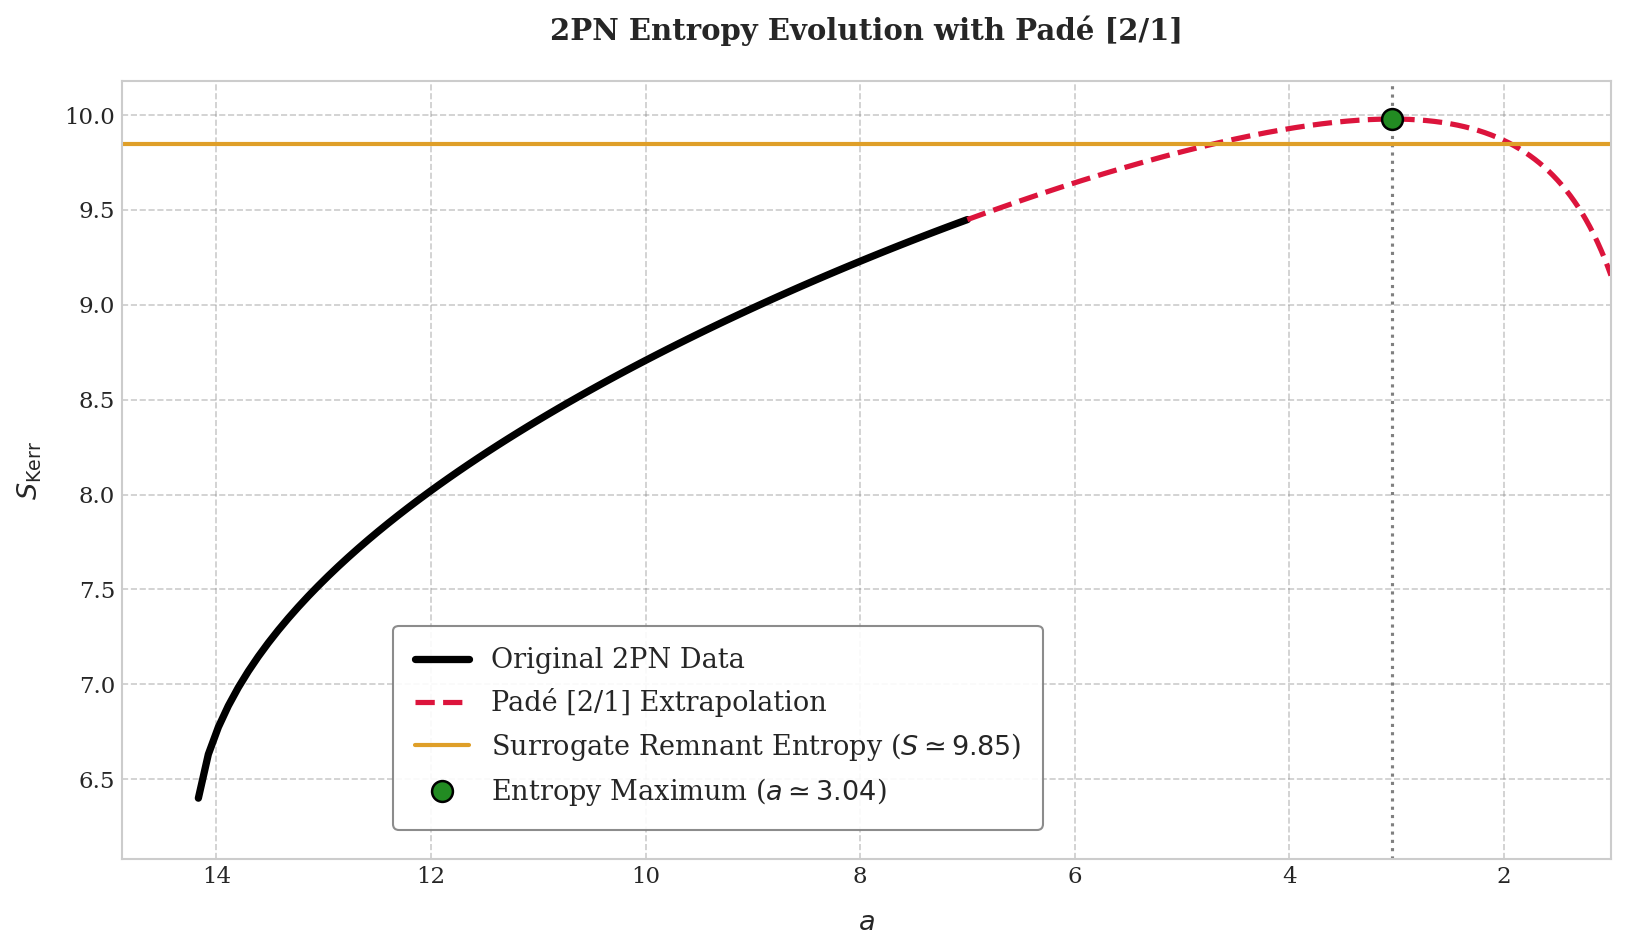

In [119]:
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'serif'
})

fig, ax = plt.subplots(figsize=(11, 6.5), dpi=150)
ax.plot(a_fit, S_fit, color='black', lw=3.5, label='Original 2PN Data')
ax.plot(a_extrap, ENT_extrap, color='#dc143c', linestyle='--', lw=2.5, label='Padé [2/1] Extrapolation')
ax.axhline(y=S_surr_final, color='#df9f28', lw=2.0, linestyle='-', 
           label=rf'Surrogate Remnant Entropy ($S \simeq {S_surr_final:.2f}$)')
ax.axvline(x=a_max_entropy, color='gray', linestyle=':', lw=1.5, zorder=1)
ax.plot(a_max_entropy, S_max_entropy, marker='o', color='#228b22', markersize=10, 
        markeredgecolor='black', markeredgewidth=1.2, linestyle='none', zorder=5,
        label=rf'Entropy Maximum ($a \simeq {a_max_entropy:.2f}$)')
ax.invert_xaxis()
x_max_plot = np.max(a_fit) * 1.05
ax.set_xlim(x_max_plot, 1.0)
y_min_plot = np.nanmin(S_fit) * 0.95
y_max_plot = max(S_max_entropy, S_surr_final) * 1.02
ax.set_ylim(y_min_plot, y_max_plot)
ax.set_xlabel(r'$a$', fontweight='bold', labelpad=10)
ax.set_ylabel(r'$S_{\mathrm{Kerr}}$', fontweight='bold', labelpad=10)
ax.set_title('2PN Entropy Evolution with Padé [2/1]', fontweight='bold', pad=20)
ax.grid(True, which='both', linestyle='--', alpha=0.4, color='gray')
ax.legend(loc='lower center', bbox_to_anchor=(0.4, 0.02), frameon=True, 
          facecolor='white', edgecolor='gray', framealpha=0.9, shadow=False, borderpad=0.8)

plt.tight_layout()
plt.show()

POLYNOMIAL INTERPOLATION

In [120]:
valid_mask = ~np.isnan(S)
a_valid = a[valid_mask]
M_valid = M_array[valid_mask]
J_valid = J_array[valid_mask]

sort_idx = np.argsort(a_valid)
a_fit = a_valid[sort_idx]
M_fit = M_valid[sort_idx]
J_fit = J_valid[sort_idx]
S_fit = S[valid_mask][sort_idx]

x_fit = 1.0 / np.sqrt(a_fit)
degree = 4

poly_M = np.poly1d(np.polyfit(x_fit, M_fit, degree))
poly_J = np.poly1d(np.polyfit(x_fit, J_fit, degree))

a_extrap = np.linspace(np.min(a_fit), 1.0, 1000)
x_extrap = 1.0 / np.sqrt(a_extrap)

M_extrap = poly_M(x_extrap)
J_extrap = poly_J(x_extrap)
ENT_extrap = entropy(M_extrap, J_extrap)

a_full = np.concatenate([a_fit, a_extrap])
ENT_full = np.concatenate([S_fit, ENT_extrap])

idx_max = np.nanargmax(ENT_full)
a_max_entropy = a_full[idx_max]
S_max_entropy = ENT_full[idx_max]

print(f"Maximum with Taylor at a =         {a_max_entropy:.3f}")
print("2PN Taylor max entropy =          ", S_max_entropy)
print("Predicted entropy =               ", S_surr_final)
print("Delta S =                         ", np.abs(S_max_entropy - S_surr_final))

Maximum with Taylor at a =         4.375
2PN Taylor max entropy =           9.819727175747463
Predicted entropy =                9.847211398441091
Delta S =                          0.02748422269362827


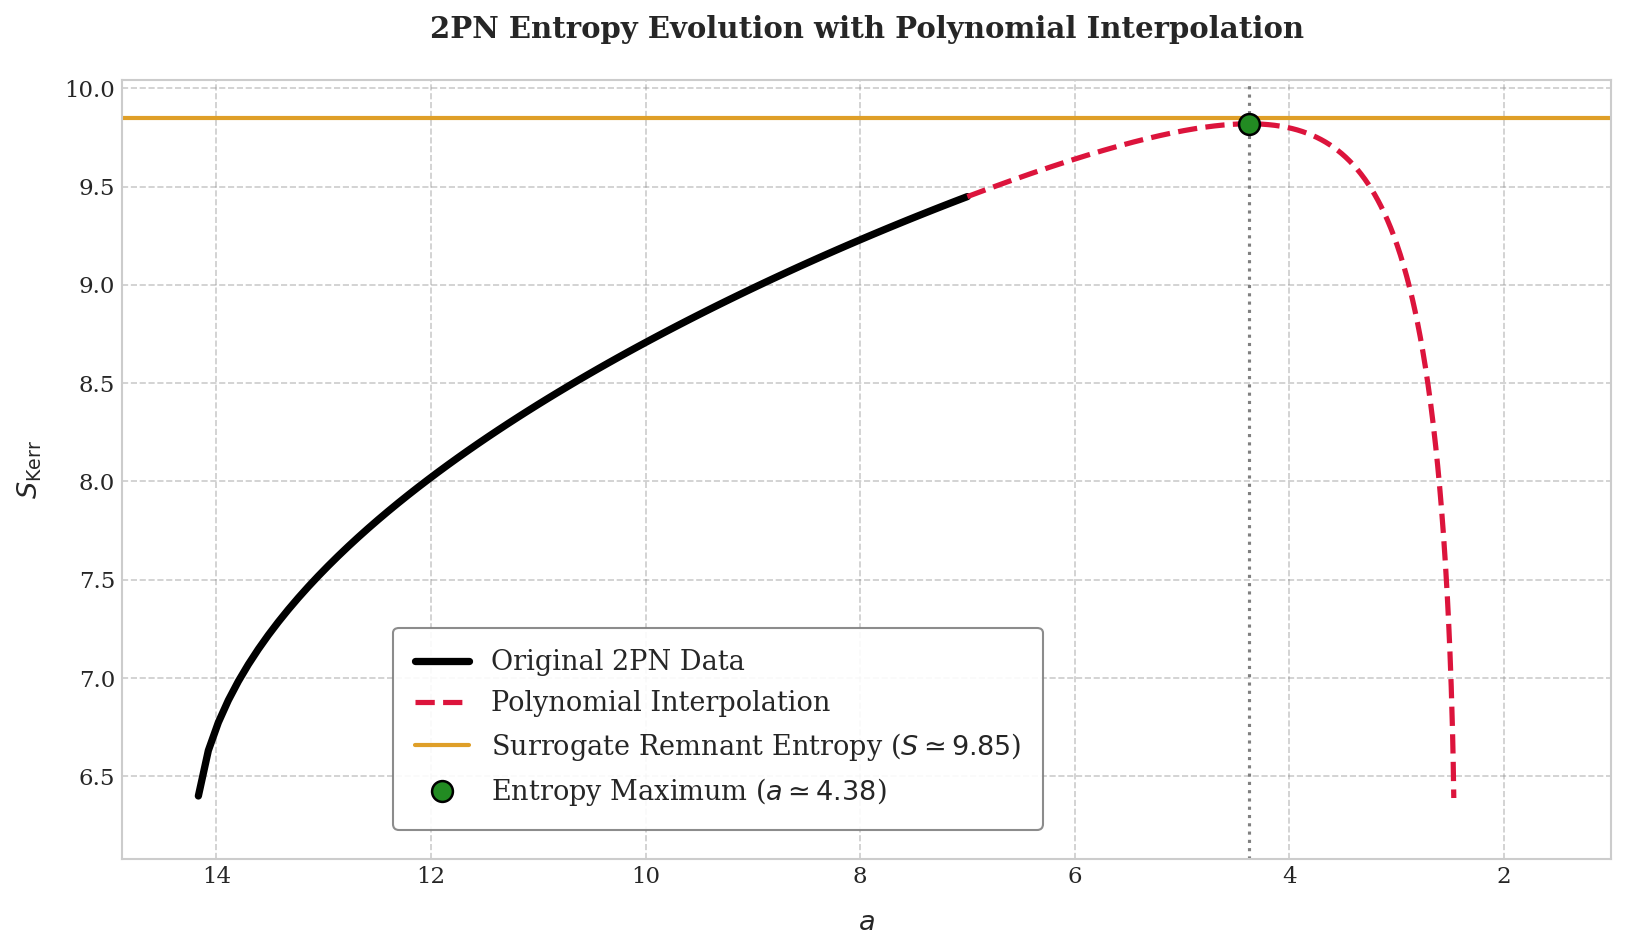

In [121]:
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'serif'
})

fig, ax = plt.subplots(figsize=(11, 6.5), dpi=150)
ax.plot(a_fit, S_fit, color='black', lw=3.5, label='Original 2PN Data')
ax.plot(a_extrap, ENT_extrap, color='#dc143c', linestyle='--', lw=2.5, label='Polynomial Interpolation')
ax.axhline(y=S_surr_final, color='#df9f28', lw=2.0, linestyle='-', 
           label=rf'Surrogate Remnant Entropy ($S \simeq {S_surr_final:.2f}$)')
ax.axvline(x=a_max_entropy, color='gray', linestyle=':', lw=1.5, zorder=1)
ax.plot(a_max_entropy, S_max_entropy, marker='o', color='#228b22', markersize=10, 
        markeredgecolor='black', markeredgewidth=1.2, linestyle='none', zorder=5,
        label=rf'Entropy Maximum ($a \simeq {a_max_entropy:.2f}$)')
ax.invert_xaxis()
x_max_plot = np.max(a_fit) * 1.05
ax.set_xlim(x_max_plot, 1.0)
y_min_plot = np.nanmin(S_fit) * 0.95
y_max_plot = max(S_max_entropy, S_surr_final) * 1.02
ax.set_ylim(y_min_plot, y_max_plot)
ax.set_xlabel(r'$a$', fontweight='bold', labelpad=10)
ax.set_ylabel(r'$S_{\mathrm{Kerr}}$', fontweight='bold', labelpad=10)
ax.set_title('2PN Entropy Evolution with Polynomial Interpolation', fontweight='bold', pad=20)
ax.grid(True, which='both', linestyle='--', alpha=0.4, color='gray')
ax.legend(loc='lower center', bbox_to_anchor=(0.4, 0.02), frameon=True, 
          facecolor='white', edgecolor='gray', framealpha=0.9, shadow=False, borderpad=0.8)

plt.tight_layout()
plt.show()

NR ANALYSIS

In [150]:
q = 3.0
m1 = q / (1.0 + q)
m2 = 1.0 / (1.0 + q)
eta = m1 * m2
chi1 = [0.0, 0.0, 0.3]
chi2 = [0.0, 0.0, 0.2]

times_NR = np.linspace(-1000, 0, 2000)

In [136]:
sur_wave_aligned = gws.LoadSurrogate('NRHybSur3dq8')
sur_remnant_aligned = surfinBH.LoadFits('NRSur3dq8Remnant')

Loaded NRHybSur3dq8 model
Loaded NRSur3dq8Remnant fit.


In [151]:
M_f, chi_f_array, _, _, _, _ = sur_remnant_aligned.all(q, chi1, chi2)
J_f = (M_f**2) * chi_f_array[2]
S_final = 2.0 * np.pi * (M_f**2) * (1.0 + np.sqrt(1.0 - (J_f/(M_f**2))**2))
print(S_final)

10.16131725054853


In [153]:
times_full = np.linspace(-5000, 0, 8000)
t_out, h_modes, _ = sur_wave_aligned(q, chi1, chi2, times=times_full, f_low=0)

dE_dt = np.zeros_like(t_out)
dJ_dt = np.zeros_like(t_out)

for (l, m), h in h_modes.items():
    dh_dt = np.gradient(h, t_out)
    dE_dt += (1.0 / (16.0 * np.pi)) * np.abs(dh_dt)**2
    dJ_dt += (1.0 / (16.0 * np.pi)) * m * np.imag(h * np.conjugate(dh_dt))

E_rad = cumulative_trapezoid(dE_dt, t_out, initial=0)
J_rad = cumulative_trapezoid(dJ_dt, t_out, initial=0)

M_init = M_f + E_rad[-1]  
J_init = J_f + J_rad[-1]

M_dyn = M_init - E_rad
J_dyn = J_init - J_rad


h22 = h_modes[(2, 2)]
phase22 = np.unwrap(np.angle(h22))
omega22 = np.gradient(phase22, t_out)
omega_orb = np.abs(omega22) / 2.0
r_sep = (np.maximum(omega_orb, 1e-8))**(-2/3)

a_spin_dyn = np.abs(J_dyn) / (M_dyn**2)

valid_kerr = a_spin_dyn <= 1.0

S_dyn = np.full_like(a_spin_dyn, np.nan)
S_dyn[valid_kerr] = 2.0 * np.pi * (M_dyn[valid_kerr]**2) * (1.0 + np.sqrt(1.0 - a_spin_dyn[valid_kerr]**2))

cutoff_idx = np.searchsorted(t_out, -12.0)
r_plot = r_sep[:cutoff_idx]
S_plot = S_dyn[:cutoff_idx]

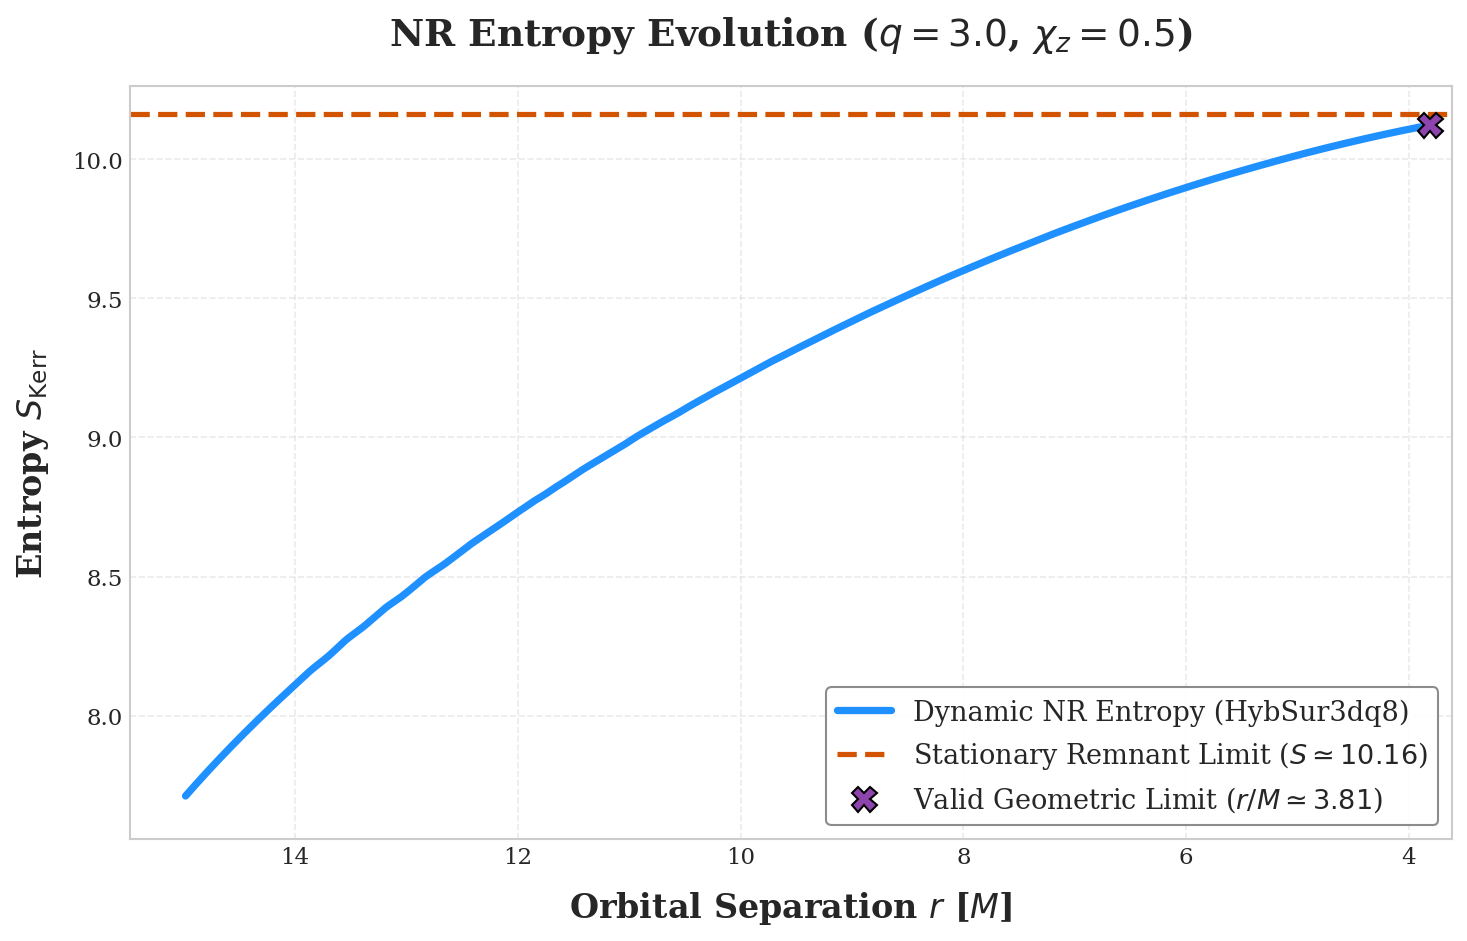

In [154]:
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 13
})

fig, ax = plt.subplots(figsize=(10, 6.5), dpi=150)
ax.plot(r_plot, S_plot, color='#1e90ff', lw=3.5, label='Dynamic NR Entropy (HybSur3dq8)')
ax.axhline(S_final, color='#d35400', linestyle='--', lw=2.5, 
           label=rf'Stationary Remnant Limit ($S \simeq {S_final:.2f}$)')
valid_r_values = r_plot[~np.isnan(S_plot)]
if len(valid_r_values) > 0:
    r_start_plot = valid_r_values[0]
else:
    r_start_plot = 15.0
ax.invert_xaxis()
ax.set_xlim(r_start_plot + 0.5, r_plot[-1] - 0.2)
y_min = np.nanmin(S_plot) * 0.98
y_max = S_final * 1.01
ax.set_ylim(y_min, y_max)
ax.plot(r_plot[-1], S_plot[-1], marker='X', color='#8e44ad', markersize=12, 
        markeredgecolor='black', linestyle='none', zorder=5, 
        label=rf'Valid Geometric Limit ($r/M \simeq {r_plot[-1]:.2f}$)')
ax.set_xlabel(r'Orbital Separation $r$ [$M$]', fontweight='bold', labelpad=10)
ax.set_ylabel(r'Entropy $S_{\mathrm{Kerr}}$', fontweight='bold', labelpad=10)
ax.set_title(rf'NR Entropy Evolution ($q={q}$, $\chi_z={chi1_z}$)', fontweight='bold', pad=20)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='gray', framealpha=0.9)
plt.tight_layout()
plt.show()